**1. CONVOLUTIONAL AUTOENCODERS TRAINING**

In [1]:
import digitalhub as dh
import pandas as pd
import matplotlib.pyplot as plt

NOME_PROGETTO = "floods"
project = dh.get_project(NOME_PROGETTO)
print(f"Progetto: {project.name}")

Progetto: floods


**SETUP ENVIRONMENT**

In [16]:
encoders_train_func = project.new_function(
    name="encoders-Floods_test-time",
    kind="python",
    python_version="PYTHON3_10",
    code_src="../src/", 
    handler="pretrain_encoders", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30"]
)

volumi = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "250Gi"}   
    }
]

build = encoders_train_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")


2026-08-13 15:10:47,723 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 6285ccac82514378a10aa44e2edccd05 to finish...
2026-08-13 15:10:52,732 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 6285ccac82514378a10aa44e2edccd05 to finish...
2026-08-13 15:10:57,749 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 6285ccac82514378a10aa44e2edccd05 to finish...
2026-08-13 15:11:02,762 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 6285ccac82514378a10aa44e2edccd05 to finish...
2026-08-13 15:11:07,775 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 6285ccac82514378a10aa44e2edccd05 to finish...
2026-08-13 15:11:12,788 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 6285ccac82514378a10aa44e2edccd05 to finish...
2026-08-13 15:11:17,805 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 6285ccac82514378a10aa44e2edccd05 to finish...
2026-08-13 15

BUILD: COMPLETED


**TRAINING**

In [17]:
parametri = {
    "epochs": 1, 
    "batch_size": 16, 
    "lr": 1e-4, 
    "weight_decay": 1e-4,      
    "patch_size": 256, 
    "n_images1": 4, "n_channels1": 2,                       # sar
    "n_images2": 4, "n_channels2": 10,                      # ottiche               
    "mamba": False, 
    "workers": 0
}

print(f"PARAMETRI: {parametri}")

run_train_encoders = encoders_train_func.run(
    action="job", 
    parameters=parametri, 
    volumes=volumi, 
    profile="1xV100",                                       # 1x = 1 gpu
    # local_execution= True,                                
    wait=True
)

print(f"Run train_encoders avviato: {run_train_encoders.id}")

2026-08-13 15:11:57,276 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 40031867e12c4aaca481196d56b80519 to finish...


PARAMETRI: {'epochs': 1, 'batch_size': 16, 'lr': 0.0001, 'weight_decay': 0.0001, 'patch_size': 256, 'n_images1': 4, 'n_channels1': 2, 'n_images2': 4, 'n_channels2': 10, 'mamba': False, 'workers': 0}


2026-08-13 15:12:02,288 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 40031867e12c4aaca481196d56b80519 to finish...
2026-08-13 15:12:07,305 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 40031867e12c4aaca481196d56b80519 to finish...
2026-08-13 15:12:12,433 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 40031867e12c4aaca481196d56b80519 to finish...
2026-08-13 15:12:17,448 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 40031867e12c4aaca481196d56b80519 to finish...
2026-08-13 15:12:22,566 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 40031867e12c4aaca481196d56b80519 to finish...
2026-08-13 15:12:27,578 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 40031867e12c4aaca481196d56b80519 to finish...
2026-08-13 15:12:32,592 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 40031867e12c4aaca481196d56b80519 to finish...
2026-08-13 15

Run train_encoders avviato: 40031867e12c4aaca481196d56b80519


In [12]:
# rieseguibile
run_train_encoders.refresh()
print(run_train_encoders.status.state)
print(run_train_encoders.status.message)
print(run_train_encoders.logs())

COMPLETED
None
[{'kind': 'log', 'metadata': {'project': 'floods', 'name': '9bc4c4676ab14c0c853689fef1dcd5df', 'version': 'electric-hawk', 'created': '2026-08-13T10:16:58.17Z', 'updated': '2026-08-13T14:55:36.219Z', 'created_by': 'mbarborini@fbk.eu', 'updated_by': 'mbarborini@fbk.eu'}, 'spec': {'run': '21b14b4ef9ae454ca4910494fd347712', 'timestamp': 1786616218168}, 'status': {'state': 'CREATED', 'container': 'init-container-21b14b4ef9ae454ca4910494fd347712', 'pod': 'j-pythonjob-21b14b4ef9ae454ca4910494fd347712-wrv6d', 'namespace': 'rsde-platform', 'containerId': '2512e8132e4a5674b31117a60ccd28eb0e7aae21cf3108028596143ed993a017'}, 'user': 'mbarborini@fbk.eu', 'project': 'floods', 'name': '9bc4c4676ab14c0c853689fef1dcd5df', 'id': '9bc4c4676ab14c0c853689fef1dcd5df', 'key': 'store://floods/log/log/9bc4c4676ab14c0c853689fef1dcd5df:9bc4c4676ab14c0c853689fef1dcd5df'}, {'kind': 'log', 'metadata': {'project': 'floods', 'name': '6d7ec8250a644a2985eb629e3ae7c9e1', 'version': 'balanced-bear', 'crea

**PLOTS**

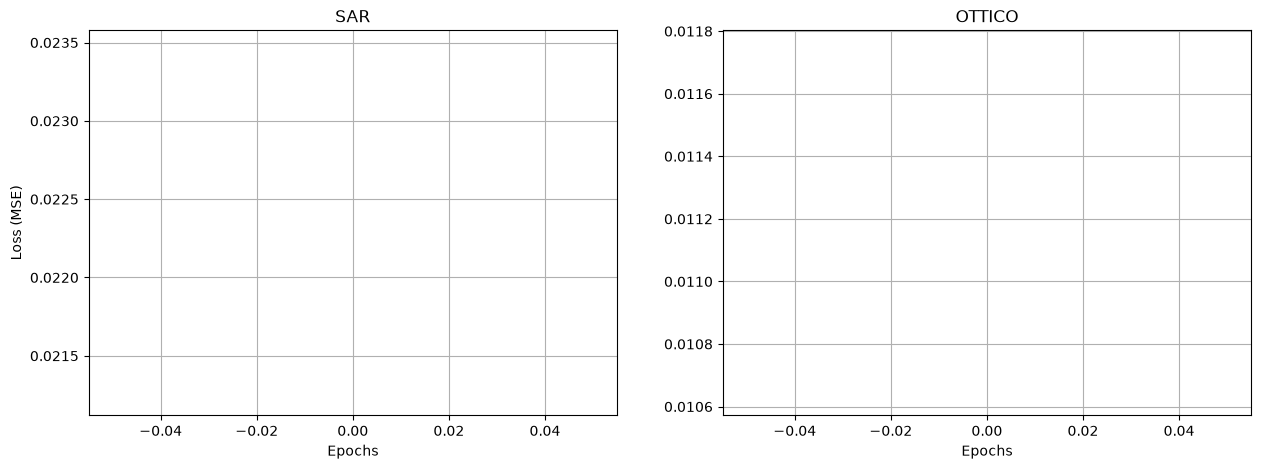

In [14]:
# salvataggio log
path_s1 = project.get_artifact("metrics-s1").download(overwrite=True)
path_s2 = project.get_artifact("metrics-s2").download(overwrite=True)

df_s1 = pd.read_csv(path_s1)
df_s2 = pd.read_csv(path_s2)

# plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# sar
ax1.plot(df_s1['epoch'], df_s1['train_loss'], color='blue', label='Train Loss')
ax1.set_title('SAR')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)')
ax1.grid(True)

# ottico
ax2.plot(df_s2['epoch'], df_s2['train_loss'], color='red', label='Train Loss')
ax2.set_title('OTTICO')
ax2.set_xlabel('Epochs')
ax2.grid(True)

plt.show()
